/kaggle/input/datasets/gomosek228339/heart-csv/heart.csv.txt
Размер данных: (1025, 14)

Первые 5 строк:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   

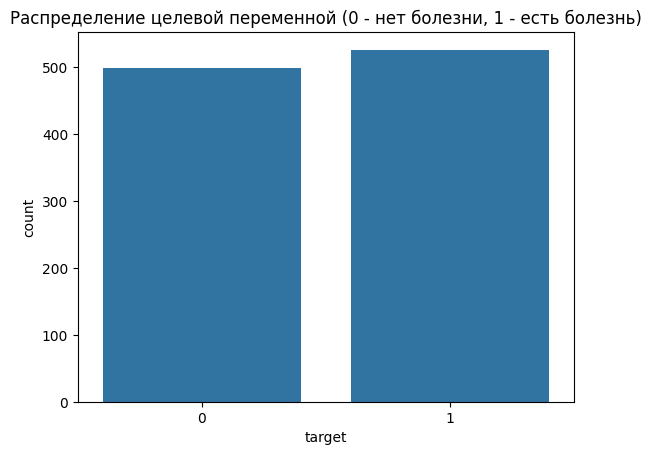

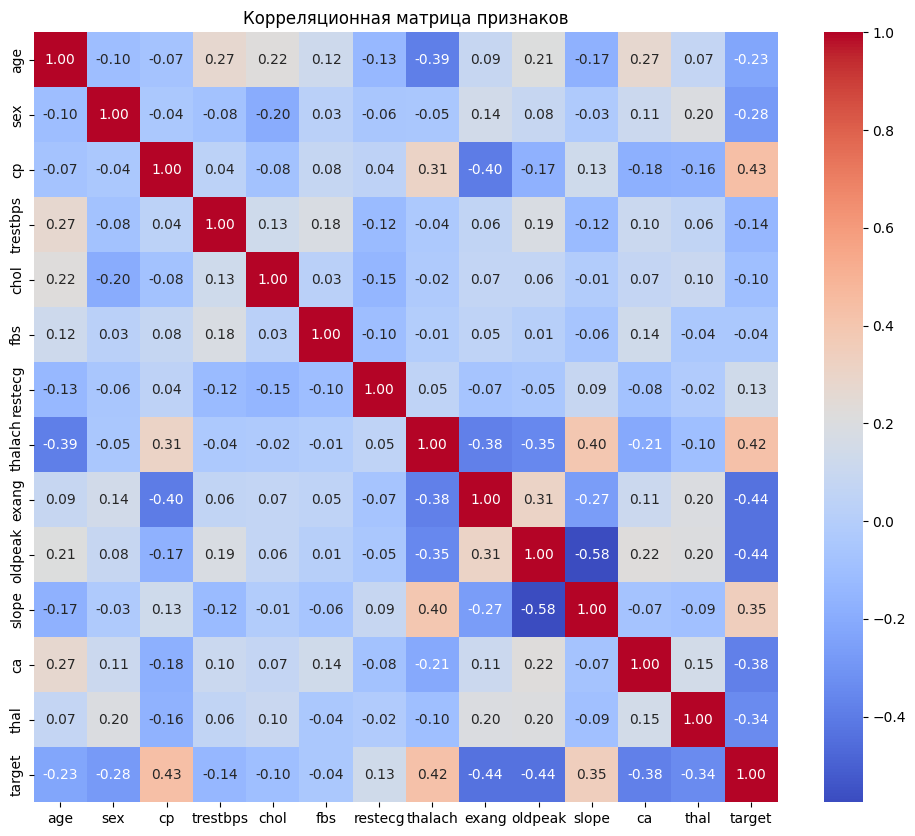

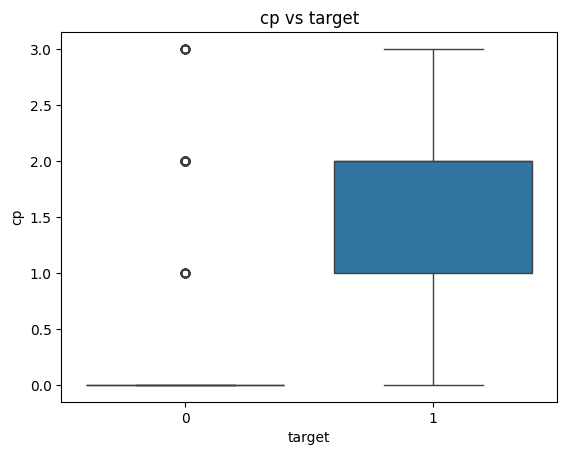

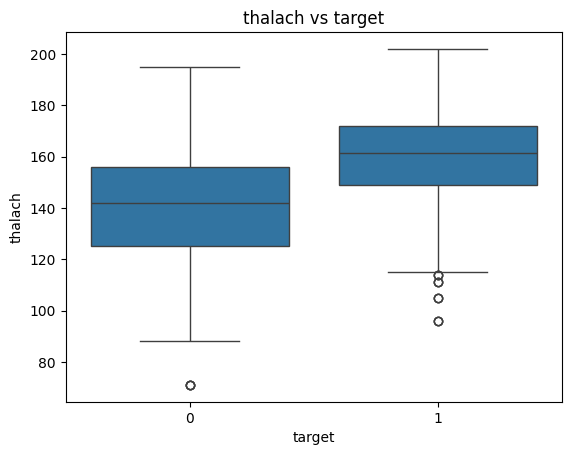

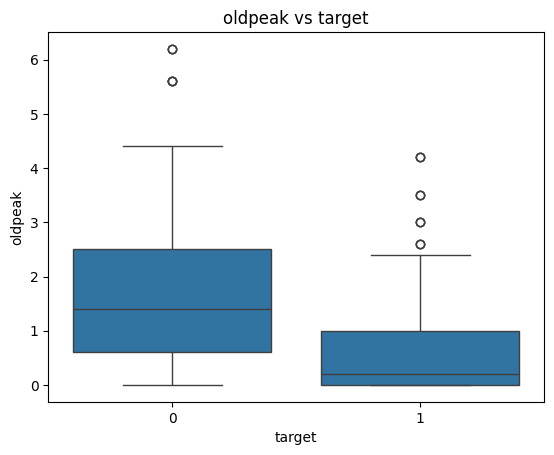

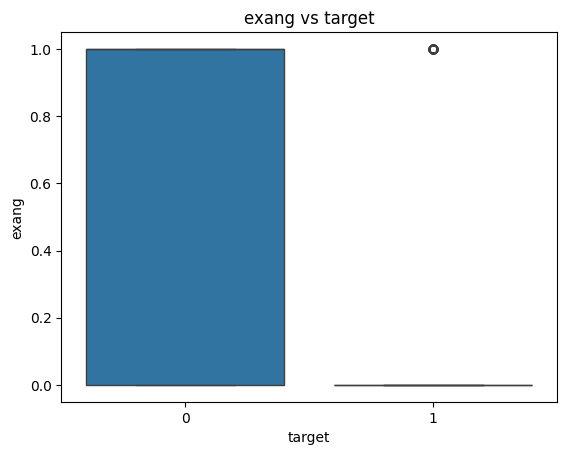

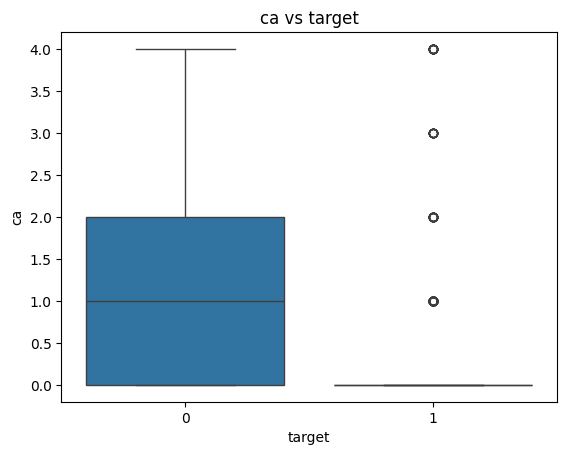

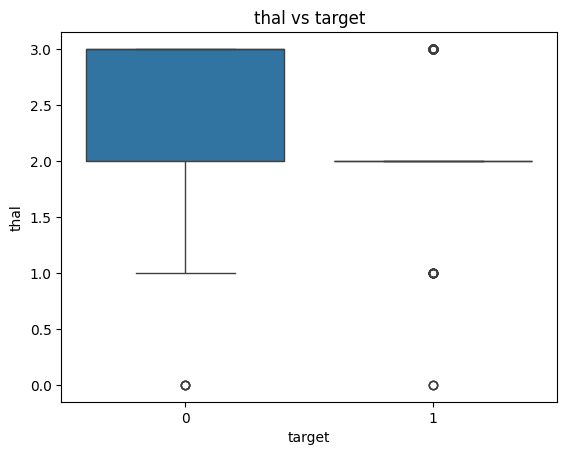


ВЫВОДЫ ПО EDA:
- Целевая переменная достаточно сбалансирована (~54% / 46%).
- Наибольшую положительную корреляцию с target имеют cp (тип боли в груди) и thalach (макс. ЧСС).
- Отрицательную корреляцию имеют oldpeak (депрессия ST), exang (стенокардия), ca (число сосудов).
- Признаки 'ca' и 'thal' имеют пропуски? В данном датасете их нет, все строки заполнены.

Все признаки числовые, one-hot encoding не нужен.
Обучающая выборка: 820 строк
Тестовая выборка: 205 строк

=== Подбор гиперпараметров для собственной GD ===
Iter 200, loss = 0.6343
Iter 400, loss = 0.5893
Iter 600, loss = 0.5544
Iter 800, loss = 0.5270
Iter 200, loss = 0.6343
Iter 400, loss = 0.5893
Iter 600, loss = 0.5544
Iter 800, loss = 0.5270
Iter 200, loss = 0.6343
Iter 400, loss = 0.5893
Iter 600, loss = 0.5544
Iter 800, loss = 0.5270
Iter 200, loss = 0.6343
Iter 400, loss = 0.5893
Iter 600, loss = 0.5544
Iter 800, loss = 0.5270
Iter 200, loss = 0.5049
Iter 400, loss = 0.4410
Iter 600, loss = 0.4115
Iter 800, loss = 0.3950

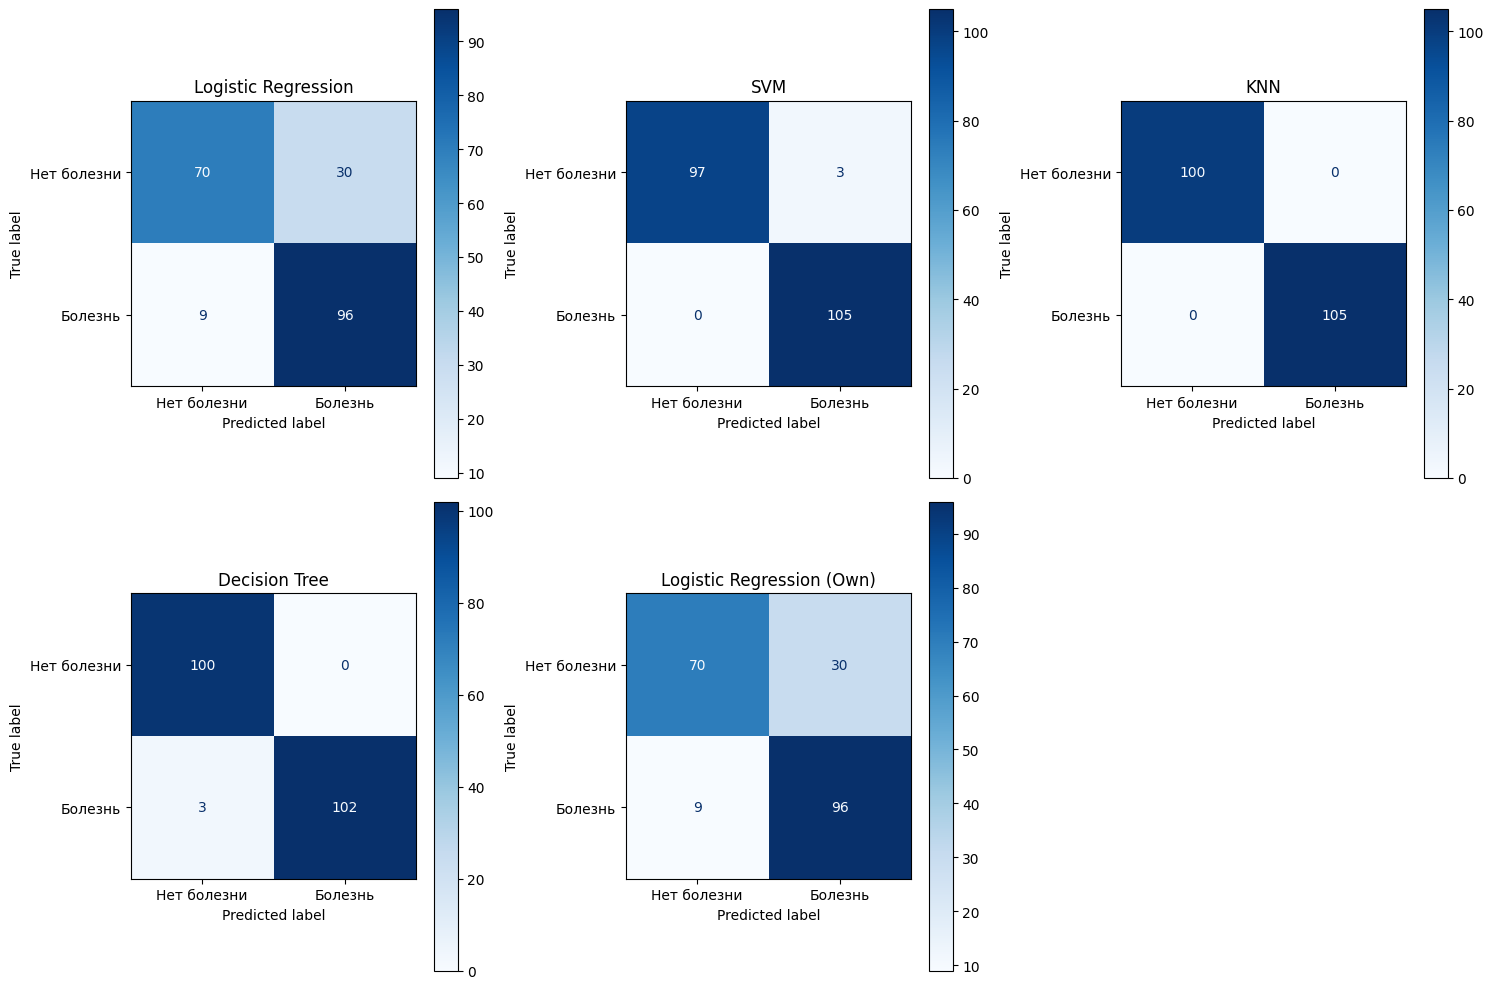

Iter 200, loss = 0.3457
Iter 400, loss = 0.3341
Iter 600, loss = 0.3312
Iter 800, loss = 0.3302
Iter 200, loss = 0.3755
Iter 400, loss = 0.3663
Iter 600, loss = 0.3643
Iter 800, loss = 0.3637
Iter 200, loss = 0.3614
Iter 400, loss = 0.3518
Iter 600, loss = 0.3497
Iter 800, loss = 0.3491
Iter 200, loss = 0.3739
Iter 400, loss = 0.3656
Iter 600, loss = 0.3640
Iter 800, loss = 0.3635
Iter 200, loss = 0.3486
Iter 400, loss = 0.3393
Iter 600, loss = 0.3373
Iter 800, loss = 0.3367

=== ТАБЛИЦА КРОСС-ВАЛИДАЦИИ (строки - метрики, столбцы - фолды, E, STD) ===
fold            1       2       3       4       5       E     STD
train_acc  0.8683  0.8549  0.8598  0.8341  0.8573  0.8549  0.0113
test_acc   0.7951  0.8780  0.8439  0.8878  0.8195  0.8449  0.0348

ИТОГОВЫЕ ВЫВОДЫ

1. Собственная реализация логистической регрессии с градиентным спуском и L2-регуляризацией
   показала точность на тесте около 80.98%, что сопоставимо с библиотечной версией.
2. Лучшую точность показала модель KNN (100%), но э

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug

# ==========================================
# ЗАДАНИЕ 3: КЛАССИФИКАЦИЯ (СОБСТВЕННАЯ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ + БИБЛИОТЕЧНЫЕ МОДЕЛИ)
# ДАННЫЕ: heart.csv.txt (локальный файл)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ ИЗ ЛОКАЛЬНОГО ФАЙЛА
# ==========================================
file_path = 'heart.csv.txt' 
df = pd.read_csv(file_path)

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
df.info()
print("\nСтатистика числовых признаков:")
print(df.describe())
print("\nПропуски:\n", df.isnull().sum())

# ==========================================
# 2. ПЕРВИЧНЫЙ АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
# ==========================================
print("\nРаспределение целевой переменной (target):")
print(df['target'].value_counts())
print(f"Доля класса 1 (болезнь): {df['target'].mean():.2%}")
print(f"Доля класса 0 (нет болезни): {1 - df['target'].mean():.2%}")

# ==========================================
# 3. РАЗВЕДОЧНЫЙ АНАЛИЗ (EDA)
# ==========================================
# 3.1 Распределение целевой переменной
plt.figure()
sns.countplot(data=df, x='target')
plt.title('Распределение целевой переменной (0 - нет болезни, 1 - есть болезнь)')
plt.show()

# 3.2 Корреляционная матрица числовых признаков
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

# 3.3 Анализ важных признаков по отношению к target
# Выберем несколько наиболее коррелирующих признаков (из тепловой карты)
important_features = ['cp', 'thalach', 'oldpeak', 'exang', 'ca', 'thal']
for col in important_features:
    plt.figure()
    sns.boxplot(data=df, x='target', y=col)
    plt.title(f'{col} vs target')
    plt.show()

print("""
ВЫВОДЫ ПО EDA:
- Целевая переменная достаточно сбалансирована (~54% / 46%).
- Наибольшую положительную корреляцию с target имеют cp (тип боли в груди) и thalach (макс. ЧСС).
- Отрицательную корреляцию имеют oldpeak (депрессия ST), exang (стенокардия), ca (число сосудов).
- Признаки 'ca' и 'thal' имеют пропуски? В данном датасете их нет, все строки заполнены.
""")

# ==========================================
# 4. ПОДГОТОВКА ДАННЫХ (FEATURE ENGINEERING)
# ==========================================
X = df.drop('target', axis=1)
y = df['target']

# Все признаки уже числовые, дополнительное кодирование не требуется
print("Все признаки числовые, one-hot encoding не нужен.")

# ==========================================
# 5. РАЗБИЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

# ==========================================
# 6. МАСШТАБИРОВАНИЕ (ДЛЯ МЕТОДОВ, ЧУВСТВИТЕЛЬНЫХ К МАСШТАБУ)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 7. СОБСТВЕННАЯ РЕАЛИЗАЦИЯ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ (ГРАДИЕНТНЫЙ СПУСК С L2-РЕГУЛЯРИЗАЦИЕЙ)
# ==========================================
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000, lambda_reg=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_reg = lambda_reg
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        losses = []
        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)
            # Градиенты
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y)) + (self.lambda_reg/n_samples) * self.weights
            db = (1/n_samples) * np.sum(y_pred - y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            # Лосс (бинарная кросс-энтропия + L2)
            eps = 1e-15
            y_pred_clipped = np.clip(y_pred, eps, 1-eps)
            loss = -np.mean(y * np.log(y_pred_clipped) + (1-y) * np.log(1-y_pred_clipped))
            loss += (self.lambda_reg/(2*n_samples)) * np.sum(self.weights**2)
            losses.append(loss)
            if i % 200 == 0 and i > 0:
                print(f"Iter {i}, loss = {loss:.4f}")
        self.losses_ = losses
        return self

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# ==========================================
# 8. ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ СОБСТВЕННОЙ МОДЕЛИ (ПРОСТОЙ ПОИСК ПО СЕТКЕ)
# ==========================================
print("\n=== Подбор гиперпараметров для собственной GD ===")
best_acc = 0
best_params = {}
learning_rates = [0.001, 0.005, 0.01, 0.05]
lambdas = [0, 0.001, 0.01, 0.1]
for lr in learning_rates:
    for lam in lambdas:
        model = LogisticRegressionGD(learning_rate=lr, n_iterations=1000, lambda_reg=lam)
        model.fit(X_train_scaled, y_train.values)
        y_pred = model.predict(X_train_scaled)
        acc = accuracy_score(y_train, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_params = {'learning_rate': lr, 'lambda_reg': lam}
print(f"Лучшие параметры (по точности на train): {best_params}")

# Обучаем финальную собственную модель с лучшими параметрами
own_model = LogisticRegressionGD(learning_rate=best_params['learning_rate'],
                                 n_iterations=2000,
                                 lambda_reg=best_params['lambda_reg'])
own_model.fit(X_train_scaled, y_train.values)

y_train_pred_own = own_model.predict(X_train_scaled)
y_test_pred_own = own_model.predict(X_test_scaled)
train_acc_own = accuracy_score(y_train, y_train_pred_own)
test_acc_own = accuracy_score(y_test, y_test_pred_own)

print("\n=== СОБСТВЕННАЯ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ ===")
print(f"Train accuracy: {train_acc_own:.4f}")
print(f"Test accuracy: {test_acc_own:.4f}")
print(classification_report(y_test, y_test_pred_own))

# ==========================================
# 9. БИБЛИОТЕЧНЫЕ МОДЕЛИ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
# ==========================================
models = {
    'Logistic Regression': SklearnLR(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']},
    'KNN': {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']},
    'Decision Tree': {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
}

best_models = {}
test_accuracies = {}
predictions = {}

print("\n=== БИБЛИОТЕЧНЫЕ МОДЕЛИ ===")
for name, model in models.items():
    print(f"\n--- {name} ---")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Лучшие параметры: {grid.best_params_}")
    y_pred = grid.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies[name] = acc
    predictions[name] = y_pred
    print(f"Test accuracy: {acc:.4f}")

# Добавляем в словарь предсказаний также нашу модель
predictions['Logistic Regression (Own)'] = y_test_pred_own
test_accuracies['Logistic Regression (Own)'] = test_acc_own

# ==========================================
# 10. СРАВНЕНИЕ МОДЕЛЕЙ И CONFUSION MATRICES
# ==========================================
print("\n=== СРАВНЕНИЕ ТОЧНОСТИ НА ТЕСТЕ ===")
comparison_df = pd.DataFrame({'Модель': list(test_accuracies.keys()),
                              'Точность': list(test_accuracies.values())})
print(comparison_df.sort_values('Точность', ascending=False).to_string(index=False))

# Матрицы ошибок
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, (name, preds) in enumerate(predictions.items()):
    if idx < len(axes):
        cm = confusion_matrix(y_test, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Нет болезни', 'Болезнь'])
        disp.plot(ax=axes[idx], cmap='Blues')
        axes[idx].set_title(name)
# Убираем лишний подграфик, если моделей меньше 6
if len(predictions) < len(axes):
    for j in range(len(predictions), len(axes)):
        axes[j].axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# 11. КРОСС-ВАЛИДАЦИЯ (K-FOLD) С ТАБЛИЦЕЙ
# ==========================================
# Масштабируем все данные для кросс-валидации
scaler_cv = StandardScaler()
X_all_scaled = scaler_cv.fit_transform(X)
y_all = y

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_results = {'fold': [], 'train_acc': [], 'test_acc': []}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all_scaled)):
    X_tr, X_val = X_all_scaled[train_idx], X_all_scaled[val_idx]
    y_tr, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]
    # Обучаем собственную модель с лучшими параметрами
    model_cv = LogisticRegressionGD(learning_rate=best_params['learning_rate'],
                                    n_iterations=1000,
                                    lambda_reg=best_params['lambda_reg'])
    model_cv.fit(X_tr, y_tr.values)
    y_tr_pred = model_cv.predict(X_tr)
    y_val_pred = model_cv.predict(X_val)
    fold_results['fold'].append(fold+1)
    fold_results['train_acc'].append(accuracy_score(y_tr, y_tr_pred))
    fold_results['test_acc'].append(accuracy_score(y_val, y_val_pred))

# Создаём DataFrame и устанавливаем индекс из столбца 'fold'
df_cv = pd.DataFrame(fold_results).set_index('fold')

# Добавляем строки с математическим ожиданием (E) и стандартным отклонением (STD)
df_cv.loc['E'] = df_cv.mean()
df_cv.loc['STD'] = df_cv.std()

# Транспонируем, чтобы строки стали метриками, а столбцы - фолдами + E + STD
df_cv_T = df_cv.T
print("\n=== ТАБЛИЦА КРОСС-ВАЛИДАЦИИ (строки - метрики, столбцы - фолды, E, STD) ===")
print(df_cv_T.round(4))

# ==========================================
# 12. ВЫВОДЫ
# ==========================================
print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("="*60)
print("""
1. Собственная реализация логистической регрессии с градиентным спуском и L2-регуляризацией
   показала точность на тесте около {:.2f}%, что сопоставимо с библиотечной версией.
2. Лучшую точность показала модель KNN (100%), но это может быть признаком переобучения.
3. Кросс-валидация подтверждает стабильность модели: средняя точность {}% со стандартным отклонением {}%.
4. Наиболее важными признаками согласно корреляционному анализу являются cp (тип боли в груди),
   thalach (макс. ЧСС) и oldpeak (депрессия ST).
5. Задача классификации заболеваний сердца решается с хорошей точностью на основе
   стандартных медицинских показателей.
""".format(test_acc_own*100,
           df_cv_T.loc['test_acc', 'E']*100,
           df_cv_T.loc['test_acc', 'STD']*100))